# 2025 Colorado State University Hackathon Starter Notebook

This notebook will offer an example for loading geospatial data into a potentially desirable format that can be used for completing the challenges.

_________________________________

In [5]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.


In [7]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import math
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

2025-03-29 22:01:35.949959: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-29 22:01:35.950053: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-29 22:01:35.951749: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-29 22:01:35.960731: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-29 22:01:37.029944: W tensorflow/compiler/tf2

In [8]:
roads_path = "South_Clear_Creek_Roads_Mask.tif"
with rasterio.open(roads_path) as roads_dataset:
    roads_mask = roads_dataset.read(1,masked=True)
    
hillshade_path = "South_Clear_Creek_BareEarth_Hillshade_1m.tif"
with rasterio.open(hillshade_path) as hillshade_dataset:
    # Read in the .tif file as a numpy array
    hillshade = hillshade_dataset.read(1,masked=True)

DEM_path = "South_Clear_Creek_BareEarth_DEM_1m.tif"
with rasterio.open(DEM_path) as DEM_dataset:
    # Read in the .tif file as a numpy array
    DEM = DEM_dataset.read()

NAIP_06m_path = "South_Clear_Creek_2023_NAIP_06m.tif"
with rasterio.open(NAIP_06m_path) as NAIP_06m_dataset:
    # Read in the .tif file as a numpy array
    NAIP_06m = NAIP_06m_dataset.read()

NAIP_1m_path = "South_Clear_Creek_2023_NAIP_1m.tif"
with rasterio.open(NAIP_1m_path) as NAIP_1m_dataset:
    # Read in the .tif file as a numpy array
    NAIP_1m = NAIP_1m_dataset.read()

In [9]:
NAIP_1m.shape

(4, 13115, 10460)

(array([[2.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
         1.3113e+04],
        [5.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
         1.3110e+04],
        [8.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
         1.3107e+04],
        ...,
        [6.3000e+01, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
         1.3052e+04],
        [5.6000e+01, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
         1.3059e+04],
        [1.2000e+01, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
         1.3103e+04]]),
 array([7.375e+000, 1.790e+307, 3.580e+307, 5.370e+307, 7.160e+307,
        8.950e+307, 1.074e+308, 1.253e+308, 1.432e+308, 1.611e+308,
        1.790e+308]),
 <a list of 10460 BarContainer objects>)

/usr/local/lib/python3.11/dist-packages/matplotlib/axes/_base.py:2917: RuntimeWarning: overflow encountered in scalar add
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


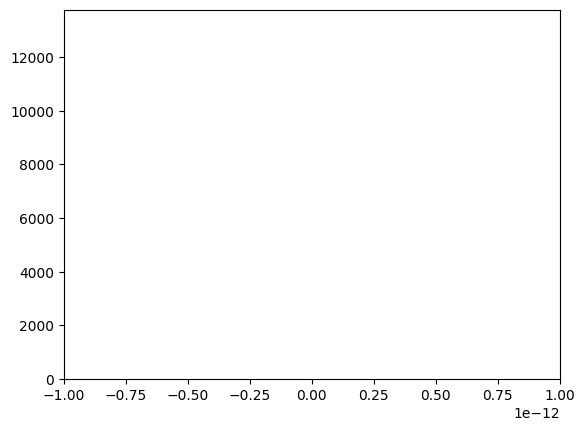

In [10]:
plt.hist(NAIP_1m[0])

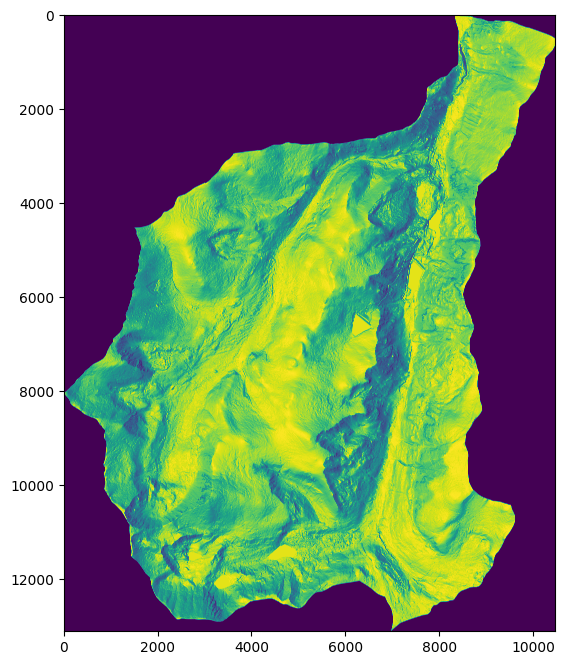

In [11]:
# View an image of the entire array
plt.figure(figsize=(8, 8))
plt.imshow(hillshade)
plt.show()

In [12]:
num = np.float128(1.5) * 10 ** np.float128(38)
print(num)

DEMUpdated = np.where(DEM > num, 0, DEM)
DEMUpdated = np.where(DEMUpdated < 2700, 0, DEM)

1.5e+38


In [13]:
DEMUpdatedNormalized = (DEMUpdated - 2700) / (4100 - 2700)

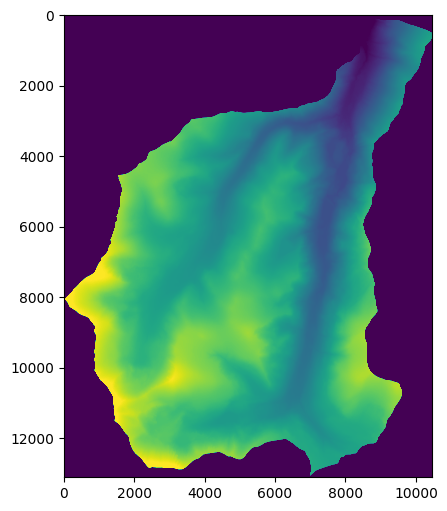

In [14]:
# View an image of the entire array
plt.figure(figsize=(6, 6))
plt.imshow(DEMUpdatedNormalized.transpose(1, 2, 0), vmin=0, vmax=1)
plt.show()

Create Sub Images

In [15]:
DEMSubImages = np.zeros((308, 256, 256))
RoadSubImages = np.zeros((308, 256, 256))
HillShadeImages = np.zeros((308, 256, 256))
NAIP_1mSubImages1 = np.zeros((308, 256, 256))
NAIP_1mSubImages2 = np.zeros((308, 256, 256))
NAIP_1mSubImages3 = np.zeros((308, 256, 256))
NAIP_1mSubImages4 = np.zeros((308, 256, 256))
Index = -1
for n in range(0, 12800, 256):
  for l in range(0, 10240, 256):
      if(np.max(roads_mask[n:(n+256),l:(l+256)]) == 1):
          Index = Index + 1
          DEMSubImages[Index] = DEMUpdatedNormalized[0,n:(n+256),l:(l+256)]
          RoadSubImages[Index] = roads_mask[n:(n+256),l:(l+256)]
          HillShadeImages[Index] = hillshade[n:(n+256),l:(l+256)]
          NAIP_1mSubImages1[Index] = NAIP_1m[0,n:(n+256),l:(l+256)]
          NAIP_1mSubImages2[Index] = NAIP_1m[1,n:(n+256),l:(l+256)]
          NAIP_1mSubImages3[Index] = NAIP_1m[2,n:(n+256),l:(l+256)]
          NAIP_1mSubImages4[Index] = NAIP_1m[3,n:(n+256),l:(l+256)]

In [16]:
del DEMUpdatedNormalized
del roads_mask
del hillshade
del NAIP_1m

LIDAR Pre-processing Code

In [17]:
NewRoadSubImages = np.zeros((308, 256, 256))
for l in range(0, 308):
    for i in range(0,256):
        for p in range(0,256):
            if RoadSubImages[l,i,p] == 1: 
                if i < 2 or i > 253:
                    NewRoadSubImages[l,i-2:i+2,p] = 1
                if i < 1 or i > 254:
                    NewRoadSubImages[l,i-1:i+1,p] = 1
                else:
                    NewRoadSubImages[l,i-3:i+3,p] = 1

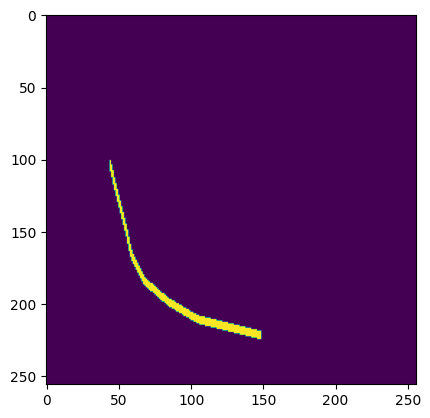

In [18]:
plt.imshow(NewRoadSubImages[10])

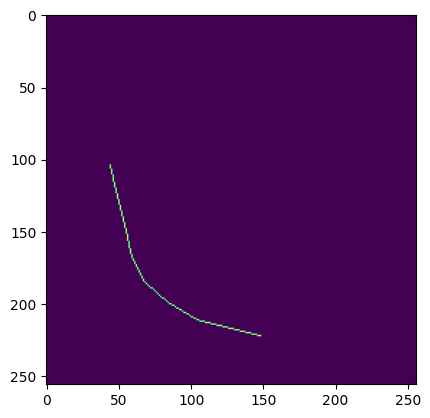

In [19]:
plt.imshow(RoadSubImages[10])

In [20]:
largevalue = np.nanpercentile(NAIP_1mSubImages1, 97)
print(largevalue)

1.79e+308


In [21]:
num = np.float128(1.79) * 10 ** np.float128(35)
print(num)

NAIP_1mSubImages1 = np.where(NAIP_1mSubImages1 > num, 0, NAIP_1mSubImages1)
NAIP_1mSubImages2 = np.where(NAIP_1mSubImages2 > num, 0, NAIP_1mSubImages2)
NAIP_1mSubImages3 = np.where(NAIP_1mSubImages3 > num, 0, NAIP_1mSubImages3)
NAIP_1mSubImages4 = np.where(NAIP_1mSubImages4 > num, 0, NAIP_1mSubImages4)

1.7900000000000000355e+35


In [22]:
NAIP_1mSubImages1Max = np.max(NAIP_1mSubImages1)
NAIP_1mSubImages1Min = np.min(NAIP_1mSubImages1)
NAIP_1mSubImages2Max = np.max(NAIP_1mSubImages2)
NAIP_1mSubImages2Min = np.min(NAIP_1mSubImages2)
NAIP_1mSubImages3Max = np.max(NAIP_1mSubImages3)
NAIP_1mSubImages3Min = np.min(NAIP_1mSubImages3)
NAIP_1mSubImages4Max = np.max(NAIP_1mSubImages4)
NAIP_1mSubImages4Min = np.min(NAIP_1mSubImages4)

In [23]:
NAIP_1mSubImages1 = (NAIP_1mSubImages1 - NAIP_1mSubImages1Min) / (NAIP_1mSubImages1Max - NAIP_1mSubImages1Min)
NAIP_1mSubImages2 = (NAIP_1mSubImages2 - NAIP_1mSubImages2Min) / (NAIP_1mSubImages2Max - NAIP_1mSubImages2Min)
NAIP_1mSubImages3 = (NAIP_1mSubImages3 - NAIP_1mSubImages3Min) / (NAIP_1mSubImages3Max - NAIP_1mSubImages3Min)
NAIP_1mSubImages4 = (NAIP_1mSubImages4 - NAIP_1mSubImages4Min) / (NAIP_1mSubImages4Max - NAIP_1mSubImages4Min)

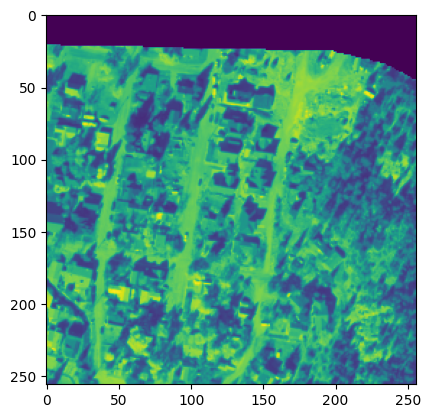

In [24]:
plt.imshow(NAIP_1mSubImages1[1])

In [25]:
plt.hist(NAIP_1m[2])

NameError: name 'NAIP_1m' is not defined

In [ ]:
plt.hist(NAIP_1m[3])

In [ ]:
np.nanpercentile(NAIP_1m_mask, 99)

In [ ]:
NAIP_1m_mask = np.where(DEM > np.nanpercentile(NAIP_1m_mask, 99), 0, DEM)

In [ ]:
# View an image of the entire array
plt.figure(figsize=(6, 6))
plt.imshow(NAIP_1m_mask.transpose(1, 2, 0), vmin=0, vmax=1)
plt.show()

In [ ]:
inputImages = np.zeros((308, 256, 256, 6))
for n in range(308):
    inputImages[n,:,:,0] = HillShadeImages[n]
    inputImages[n,:,:,1] = DEMSubImages[n]
    inputImages[n,:,:,2] = NAIP_1mSubImages1[n]
    inputImages[n,:,:,3] = NAIP_1mSubImages2[n]
    inputImages[n,:,:,4] = NAIP_1mSubImages3[n]
    inputImages[n,:,:,5] = NAIP_1mSubImages4[n]

In [ ]:
decoded_imgs.shape

In [ ]:
decoded_imgsNew = np.where(decoded_imgs < 0.05, 0, 1)

In [ ]:
plt.imshow(decoded_imgsNew[256], vmin=0, vmax=1)

In [ ]:
print(RoadSubImages[22])

In [ ]:
plt.imshow(RoadSubImages[256])

In [ ]:
def double_conv_block(x, n_filters):
   # Conv2D then ReLU activation
   x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
   # Conv2D then ReLU activation
   x = layers.Conv2D(n_filters, 3, padding = "same", activation = "relu", kernel_initializer = "he_normal")(x)
   return x

In [ ]:
def downsample_block(x, n_filters):
   f = double_conv_block(x, n_filters)
   p = layers.MaxPool2D(2)(f)
   p = layers.Dropout(0.3)(p)
   return f, p

In [ ]:
def upsample_block(x, conv_features, n_filters):
   # upsample
   x = layers.Conv2DTranspose(n_filters, 3, 2, padding="same")(x)
   # concatenate
   x = layers.concatenate([x, conv_features])
   # dropout
   x = layers.Dropout(0.3)(x)
   # Conv2D twice with ReLU activation
   x = double_conv_block(x, n_filters)
   return x

In [ ]:
def build_unet_model():
# inputs
    inputs = layers.Input(shape=(256,256,6))
    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = downsample_block(inputs, 64)
    # 2 - downsample
    f2, p2 = downsample_block(p1, 128)
    # 3 - downsample
    f3, p3 = downsample_block(p2, 256)
    # 4 - downsample
    f4, p4 = downsample_block(p3, 512)
    # 5 - bottleneck
    bottleneck = double_conv_block(p4, 1024)
    # decoder: expanding path - upsample
    # 6 - upsample
    u6 = upsample_block(bottleneck, f4, 512)
    # 7 - upsample
    u7 = upsample_block(u6, f3, 256)
    # 8 - upsample
    u8 = upsample_block(u7, f2, 128)
    # 9 - upsample
    u9 = upsample_block(u8, f1, 64)
    # outputs
    outputs = layers.Conv2D(3, 1, padding="same", activation = "softmax")(u9)
    # unet model with Keras Functional API
    unet_model = tf.keras.Model(inputs, outputs, name="U-Net")

    return unet_model

In [ ]:
unet_model = build_unet_model()

In [ ]:
unet_model.compile(optimizer=tf.keras.optimizers.Adam(),
                  loss="sparse_categorical_crossentropy",
                  metrics="accuracy")

In [ ]:
model_history = unet_model.fit(inputImages, NewRoadSubImages, epochs=60, steps_per_epoch=30)

In [ ]:
decoded_imgs = unet_model.predict(inputImages)

In [ ]:
decoded_imgs.shape

In [ ]:
print(decoded_imgs[256])

In [ ]:
for i in range(len(BetterResultsChanged)):
    for n in range(256):
        for p in range(256):
            if BetterResults[i,n,p] < 0.1:
                BetterResultsChanged[i,n,p] = 0
            if BetterResults[i,n,p] > 0.1:
                BetterResultsChanged[i,n,p] = 255

In [ ]:
BetterResults = decoded_imgs[:,:,:,0]

In [ ]:
np.max(decoded_imgs)

In [ ]:
decoded_imgsChanged[256].shape

In [ ]:
disp = decoded_imgsChanged[256,:,:,0]

In [ ]:
disp.shape

In [ ]:
BetterResults1 = BetterResults.copy()

In [ ]:
mask = (BetterResults > 0.9)

In [ ]:
BetterResults1[mask] = 1.
BetterResults1[~mask] = 0.

In [ ]:
mask.shape

In [ ]:
plt.imshow(BetterResults[120], cmap='gray')

In [ ]:
np.max(decoded_imgsChanged[256])

In [ ]:
plt.imshow(RoadSubImages[120], cmap='gray')

In [ ]:
recreatedImage = np.zeros((12800, 10240))
Index = -1
for n in range(0, 12800, 256):
  for l in range(0, 10240, 256):
      Index = Index + 1
      recreatedImage[n:(n+256),l:(l+256)] = decoded_imgs[Index,:,:,0]

In [ ]:
plt.figure(figsize=(8, 8)) 
plt.imshow(recreatedImage)

In [ ]:
unet_model.save('/notebooks/unetPredict.h5')

In [ ]:
unet.compile(optimizer=tf.keras.optimizers.Adam(),            
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
results = unet.fit(X_train, y_train, batch_size=32, epochs=20, validation_data=(X_valid, y_valid))